In [1]:
import pandas as pd
import geopandas as gpd

In [2]:
file_path = "LUCAS-SOIL-2018.csv"
gdf = gpd.read_file(file_path)

In [3]:
gdf.head(n = 10)

,Depth,POINTID,pH_CaCl2,pH_H2O,EC,OC,CaCO3,P,N,K,...,NUTS_3,TH_LAT,TH_LONG,SURVEY_DATE,Elev,LC,LU,LC0_Desc,LC1_Desc,LU1_Desc
0,0-20 cm,47862690,4.1,4.81,8.73,12.4,3,< LOD,1.1,101.9,...,AT113,47.15023795,16.13421178,06-07-18,291,C23,U120,Woodland,Other coniferous woodland,Forestry
1,0-20 cm,47882704,4.1,4.93,5.06,16.7,1,< LOD,1.3,51.2,...,AT113,47.27427248,16.17535859,06-07-18,373,C21,U120,Woodland,Spruce dominated coniferous woodland,Forestry
2,0-20 cm,47982688,4.1,4.85,12.53,47.5,1,12.3,3.1,114.8,...,AT113,47.1232602,16.28969291,02-06-18,246,C33,U120,Woodland,Other mixed woodland,Forestry
3,0-20 cm,48022702,5.5,5.8,21.1,28.1,3,< LOD,2,165.8,...,AT113,47.24569335,16.35750603,06-07-18,305,C22,U120,Woodland,Pine dominated coniferous woodland,Forestry
4,0-20 cm,48062708,6.1,6.48,10.89,19.4,2,< LOD,2.2,42.1,...,AT113,47.29637182,16.41678159,05-07-18,335,C22,U120,Woodland,Pine dominated coniferous woodland,Forestry
5,0-20 cm,48122730,6.3,6.81,14.46,18,NA,68,2,277.2,...,AT111,47.48881664,16.52059488,18-06-18,232,B18,U111,Cropland,Triticale,Agriculture (excluding fallow land and kitchen...
6,0-20 cm,48202738,5.8,6.37,17.08,12.5,NA,58.1,1.4,315.5,...,AT111,47.5541021,16.63555874,18-06-18,283,B32,U111,Cropland,Rape and turnip rape,Agriculture (excluding fallow land and kitchen...
7,0-20 cm,48222780,7.1,7.98,23.55,22.9,96,17.5,2.1,329.1,...,AT112,47.92869563,16.71115772,21-05-18,136,B82,U111,Cropland,Vineyards,Agriculture (excluding fallow land and kitchen...
8,0-20 cm,48342774,7.4,8.09,22.61,29.1,86,62.2,2.9,367.8,...,AT112,47.86505893,16.8638522,26-06-18,115,B32,U111,Cropland,Rape and turnip rape,Agriculture (excluding fallow land and kitchen...
9,0-20 cm,48442784,7.2,7.84,14.94,14.4,3,< LOD,1.6,146.2,...,AT112,47.94615773,17.00926007,11-06-18,166,B14,U111,Cropland,Rye,Agriculture (excluding fallow land and kitchen...


In [4]:
new_gdf = gdf[["POINTID", "OC", "TH_LAT", "TH_LONG", "Elev", "LU1_Desc"]]
new_gdf

,POINTID,OC,TH_LAT,TH_LONG,Elev,LU1_Desc
0,47862690,12.4,47.15023795,16.13421178,291,Forestry
1,47882704,16.7,47.27427248,16.17535859,373,Forestry
2,47982688,47.5,47.1232602,16.28969291,246,Forestry
3,48022702,28.1,47.24569335,16.35750603,305,Forestry
4,48062708,19.4,47.29637182,16.41678159,335,Forestry
...,...,...,...,...,...,...
18979,32643634,51.4,54.71334299,-6.563749244,50,Agriculture (excluding fallow land and kitchen...
18980,32703676,73.9,55.09148798,-6.625119415,34,Agriculture (excluding fallow land and kitchen...
18981,32783608,63.7,54.51510363,-6.259447941,50,Agriculture (excluding fallow land and kitchen...
18982,32783636,38.3,54.75926644,-6.358608435,122,Residential


Write this new Geodataframe into a file

In [5]:
#To convert to a file (you'll choose the format)
new_gdf.to_csv("new_file.csv")

In [6]:
#Tell which columns have the coordinate values
new_gdf = gpd.GeoDataFrame(
    new_gdf,
    geometry = gpd.points_from_xy(new_gdf.TH_LONG, new_gdf.TH_LAT)
)

In [7]:
#Set the coordinate system
new_gdf.set_crs(epsg = 4326, inplace = True)

,POINTID,OC,TH_LAT,TH_LONG,Elev,LU1_Desc,geometry
0,47862690,12.4,47.15023795,16.13421178,291,Forestry,POINT (16.13421 47.15024)
1,47882704,16.7,47.27427248,16.17535859,373,Forestry,POINT (16.17536 47.27427)
2,47982688,47.5,47.1232602,16.28969291,246,Forestry,POINT (16.28969 47.12326)
3,48022702,28.1,47.24569335,16.35750603,305,Forestry,POINT (16.35751 47.24569)
4,48062708,19.4,47.29637182,16.41678159,335,Forestry,POINT (16.41678 47.29637)
...,...,...,...,...,...,...,...
18979,32643634,51.4,54.71334299,-6.563749244,50,Agriculture (excluding fallow land and kitchen...,POINT (-6.56375 54.71334)
18980,32703676,73.9,55.09148798,-6.625119415,34,Agriculture (excluding fallow land and kitchen...,POINT (-6.62512 55.09149)
18981,32783608,63.7,54.51510363,-6.259447941,50,Agriculture (excluding fallow land and kitchen...,POINT (-6.25945 54.5151)
18982,32783636,38.3,54.75926644,-6.358608435,122,Residential,POINT (-6.35861 54.75927)


In [8]:
#Confirm the coordinate reference system of the geodataframe
new_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [9]:
new_gdf.set_index("POINTID")

,OC,TH_LAT,TH_LONG,Elev,LU1_Desc,geometry
POINTID,,,,,,
47862690,12.4,47.15023795,16.13421178,291,Forestry,POINT (16.13421 47.15024)
47882704,16.7,47.27427248,16.17535859,373,Forestry,POINT (16.17536 47.27427)
47982688,47.5,47.1232602,16.28969291,246,Forestry,POINT (16.28969 47.12326)
48022702,28.1,47.24569335,16.35750603,305,Forestry,POINT (16.35751 47.24569)
48062708,19.4,47.29637182,16.41678159,335,Forestry,POINT (16.41678 47.29637)
...,...,...,...,...,...,...
32643634,51.4,54.71334299,-6.563749244,50,Agriculture (excluding fallow land and kitchen...,POINT (-6.56375 54.71334)
32703676,73.9,55.09148798,-6.625119415,34,Agriculture (excluding fallow land and kitchen...,POINT (-6.62512 55.09149)
32783608,63.7,54.51510363,-6.259447941,50,Agriculture (excluding fallow land and kitchen...,POINT (-6.25945 54.5151)


In [10]:
new_gdf.shape

(18984, 7)

In [11]:
new_gdf.dtypes

POINTID       object
OC            object
TH_LAT        object
TH_LONG       object
Elev          object
LU1_Desc      object
geometry    geometry
dtype: object

In [12]:
#Change the numbers indicated as objects into numeric form
new_gdf['OC'] = pd.to_numeric(new_gdf['OC'], errors = 'coerce')
new_gdf['Elev'] = pd.to_numeric(new_gdf['Elev'], errors = 'coerce')
new_gdf['TH_LAT'] = pd.to_numeric(new_gdf['TH_LAT'], errors = 'coerce')
new_gdf['TH_LONG'] = pd.to_numeric(new_gdf['TH_LONG'], errors = 'coerce')

In [13]:
new_gdf.dtypes

POINTID       object
OC           float64
TH_LAT       float64
TH_LONG      float64
Elev           int64
LU1_Desc      object
geometry    geometry
dtype: object

In [14]:
#Get the most occuring value of Organic Carbon (OC) - MODE
new_gdf['OC'].mode()

0    9.9
Name: OC, dtype: float64

In [15]:
#Get the average value of Organic Carbon
new_gdf['OC'].mean()

np.float64(47.60528523932662)

In [16]:
#Get the median value of OC
new_gdf['OC'].median()

np.float64(21.8)

Map Making

<Axes: >

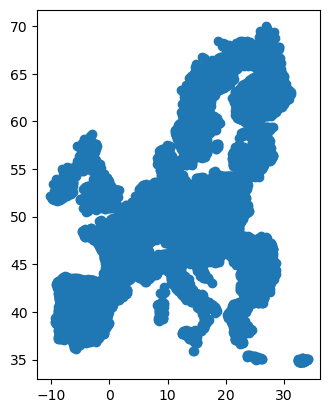

In [17]:
new_gdf.plot()

In [18]:
#The area of interest is Bavaria. Hence, the data must be clipped to the boundary of Bavaria
#Bavaria shapefile is loaded
bav_sf = gpd.read_file('Bavaria/Bav_Boundary.shp')

#Set coordinate ref system of shapefile to same CRS as geodataframe
bav_sf = bav_sf.to_crs(new_gdf.crs)

In [19]:
#Check shapefile
bav_sf

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,Shape_Leng,Shape_Area,geometry
0,DEU.2_1,DEU,Germany,Bayern,Bavaria,NA,Freistaat,Free State,09,DE.BY,DE-BY,2.588176e+06,7.053971e+10,"POLYGON ((11.41009 47.4954, 11.41005 47.49536,..."


In [20]:
#Clip data within shapefile
bav_data = gpd.clip(new_gdf, bav_sf)

In [21]:
#Confirm the data types of each column
bav_data.dtypes

POINTID       object
OC           float64
TH_LAT       float64
TH_LONG      float64
Elev           int64
LU1_Desc      object
geometry    geometry
dtype: object

<Axes: >

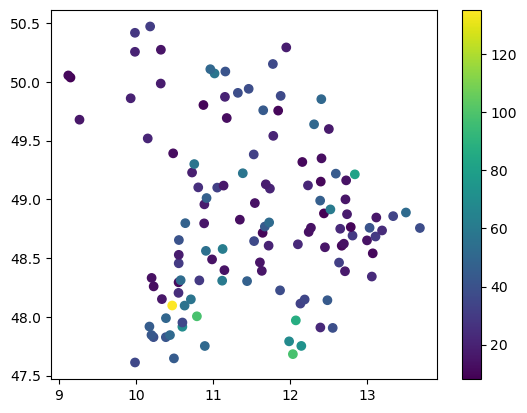

In [22]:
#Plot the clipped data
bav_data.plot("OC", legend = True)

<Axes: >

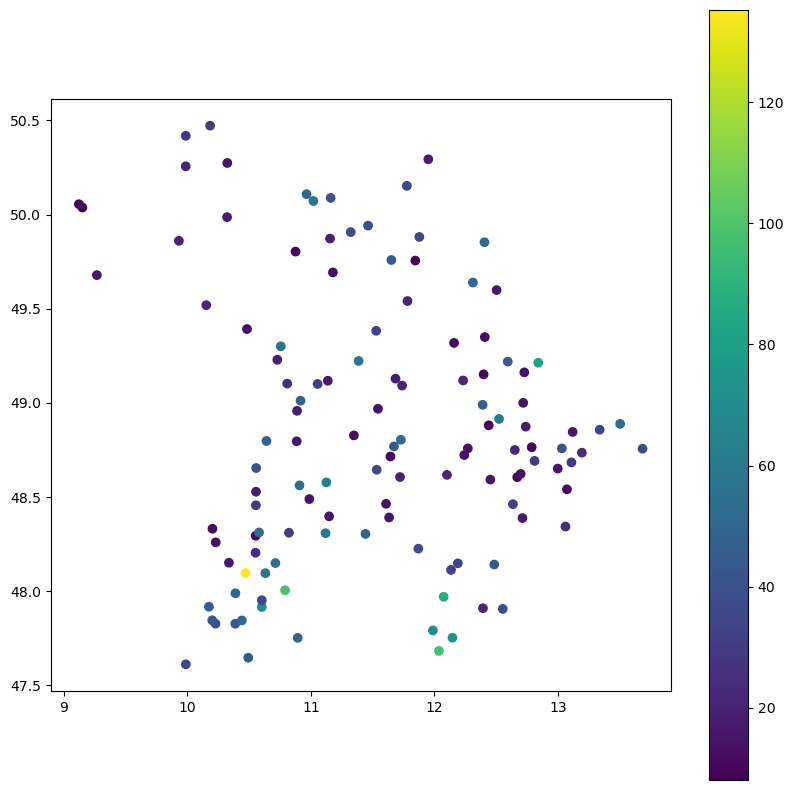

In [23]:
#To get a bigger size
bav_data.plot("OC", legend = True, figsize = (10, 10))

In [33]:
#Plot elevation on Leaflet interactive map
e = bav_data.explore("Elev", name= "Elevation", legend = True)

import folium
folium.LayerControl().add_to(e)

e

In [ ]:
#Plot elevation and OC together

#Plot elevation and save it to 'm'
m= bav_data.explore(column="Elev", cmap="terrain", name="Elevation (m)", legend = True)
#Plot OC on the same map 'm'
bav_data.explore(column="OC", cmap="YlOrBr", name="Organic Carbon", legend=True, m=m)

#Add a layer control to switch between layers
import folium
folium.LayerControl().add_to(m)

#Display map
m